# HeartMRI-FL Experiment Notebook

This notebook demonstrates a federated learning simulation with synthetic heart MRI data and a simple classification model.

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=3, no round_timeout


Built 3 client datasets
Prepared 3 federated clients from data
Starting federated learning simulation...


2026-05-12 20:53:56,233	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 100000000.0, 'node:127.0.0.1': 1.0, 'memory': 2110406400.0, 'node:__internal_head__': 1.0, 'CPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 1 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=25356) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=25356) I0000 00:00:1778599440.308871   18064 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from dif

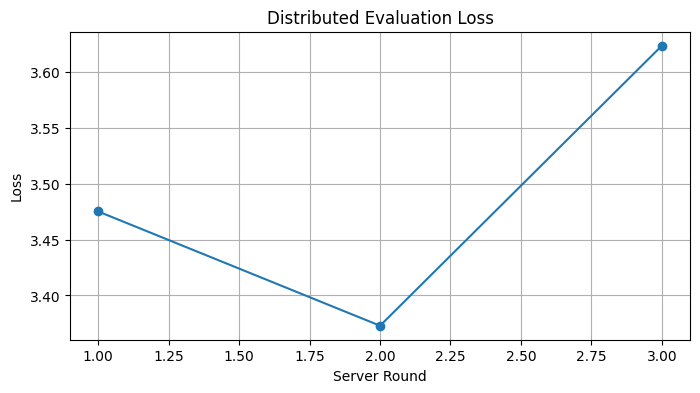

No distributed metrics recorded.


In [6]:
from pathlib import Path
import importlib
import matplotlib.pyplot as plt
import heartmri_fl.data as data_module
import heartmri_fl.federated as federated_module

importlib.reload(data_module)
importlib.reload(federated_module)
from heartmri_fl.data import build_client_data
from heartmri_fl.federated import run_federated

# Build synthetic client data. If you have DICOM/NIfTI/JPG data in ./data, that will be loaded instead.
client_data = build_client_data(
    root=Path("./data"),
    image_size=(128, 128),
    num_hospitals=3,
    num_classes=2,
)
print(f'Built {len(client_data)} client datasets')

# Run a short federated simulation directly from the notebook.
history = run_federated(
    data_root=Path("./data"),
    num_clients=3,
    num_rounds=3,
    image_size=(128, 128),
    num_classes=2,
    batch_size=16,
)

# Plot distributed evaluation loss.
if history.losses_distributed:
    rounds, losses = zip(*history.losses_distributed)
    plt.figure(figsize=(8, 4))
    plt.plot(rounds, losses, marker="o")
    plt.title("Distributed Evaluation Loss")
    plt.xlabel("Server Round")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()
else:
    print("No distributed loss records available.")

# Plot any available distributed metrics.
for metric_name, metric_values in history.metrics_distributed.items():
    rounds, values = zip(*metric_values)
    plt.figure(figsize=(8, 4))
    plt.plot(rounds, values, marker="o")
    plt.title(f"Distributed Metric: {metric_name}")
    plt.xlabel("Server Round")
    plt.ylabel(metric_name)
    plt.grid(True)
    plt.show()

if not history.metrics_distributed:
    print("No distributed metrics recorded.")

## Notes

- If you want to use real MRI data, place client subfolders under `./data` containing `.dcm` or `.nii` files.
- The notebook uses synthetic data when the data directory is empty.